In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

PMF='../../../supp_files/popc/pmfs/'

def plot_pmf(sc_label, aa_label, max_pmf, min_pmf):
# Exemple de données (à remplacer par tes vraies valeurs)
    data=pd.read_table(PMF+f'{sc_label}.dat'.lower(), sep="\s+")
    x, y, e = data['x'], data['PMF_mean']/4.184, data['std_error']/4.184 #y et e en kcal/mol
    plt.figure(figsize=(8.38, 6.00), dpi=100)
    # Fond coloré par zones
    plt.axvspan(0, 10, color="#dff0d8", alpha=0.6)   # Zone I
    plt.axvspan(10, 17.5, color="#d9d9d9", alpha=0.6)  # Zone II
    plt.axvspan(17.5, 25, color="#f2dede", alpha=0.6)  # Zone III
    plt.axvspan(25, 35, color="#d9edf7", alpha=0.6)  # Zone IV

    # Tracés
    plt.errorbar(x, y, e, fmt='', color='k', label=f'IBI-{sc_label}')

    # Étiquettes des zones
    #plt.text(5, -9, 'I', fontsize=14, fontweight='bold')
    #plt.text(12, -9, 'II', fontsize=14, fontweight='bold')
    #plt.text(20, -9, 'III', fontsize=14, fontweight='bold')
    #plt.text(30, -9, 'IV', fontsize=14, fontweight='bold')

    # Boîte ASP
    #plt.text(30.5, -8, 'ASP', fontsize=16, fontweight='bold', bbox=dict(facecolor='white', edgecolor='black'))

    # Mise en forme des axes
    plt.xlabel('Distance from the bilayer center (Å)', fontsize=12)
    plt.ylabel('Free energy (kcal/mol)', fontsize=12)
    plt.xlim(0, 35)
    plt.ylim(min_pmf, max_pmf)

    # Légende
    plt.legend(frameon=True, loc='lower left')

    # Ajustements finaux
    plt.tight_layout(pad=0)
    plt.savefig(f"{aa_label}_IBI.png", dpi=300, transparent=True)
    #plt.show()

def superposition(aa_label):
    base = Image.open(f"{aa_label}_porolegov.png").convert("RGBA")  # ton image d’origine
    overlay = Image.open(f"{aa_label}_IBI.png").convert("RGBA")              # ton graphique reproduit

    crop_box = (41, 19, base.width - 20, base.height - 32)
    cropped = base.crop(crop_box)
    # Redimensionne l’overlay pour qu’elle ait la même taille (si nécessaire)
    overlay = overlay.resize(cropped.size)

    # Ajuste la transparence si tu veux voir les deux
    overlay = overlay.copy()
    overlay.putalpha(150)  # 0 = invisible, 255 = opaque

    # Superpose
    combined = Image.alpha_composite(cropped, overlay)

    # Enregistre et affiche
    combined.save(f"superposition_{aa_label}.png")
    combined.show()


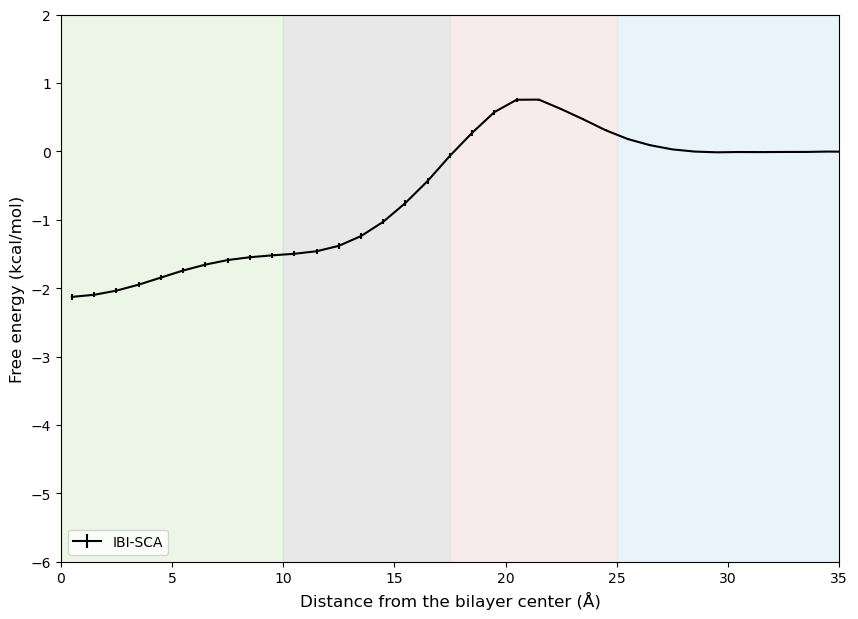

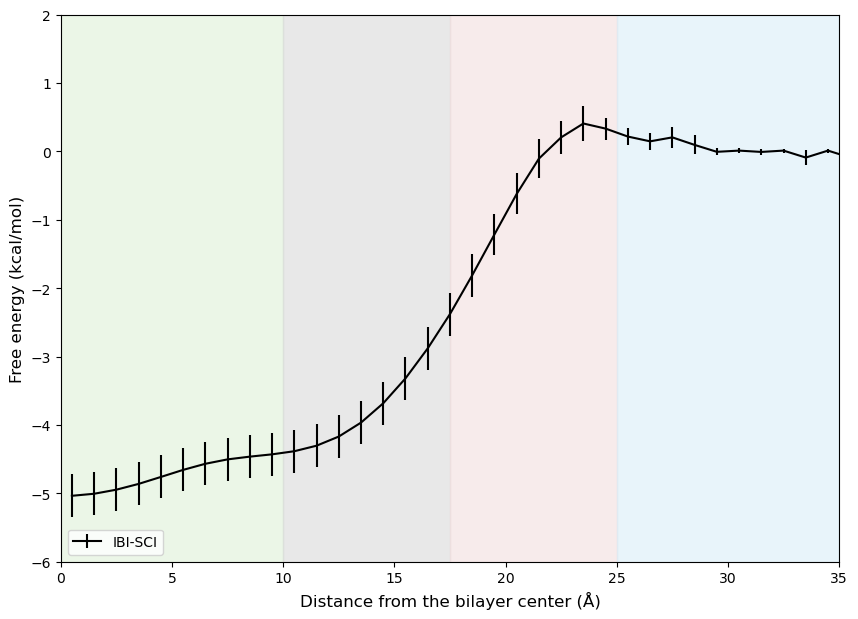

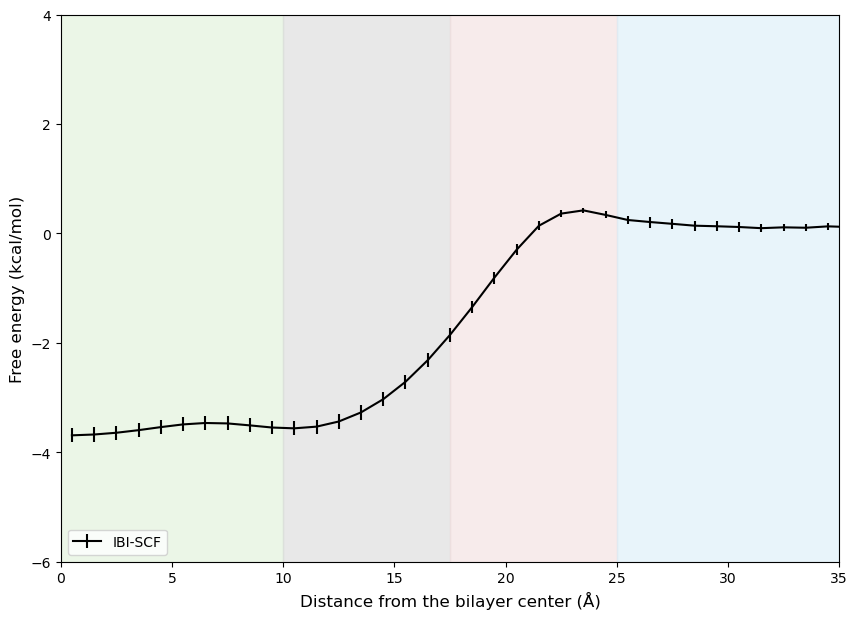

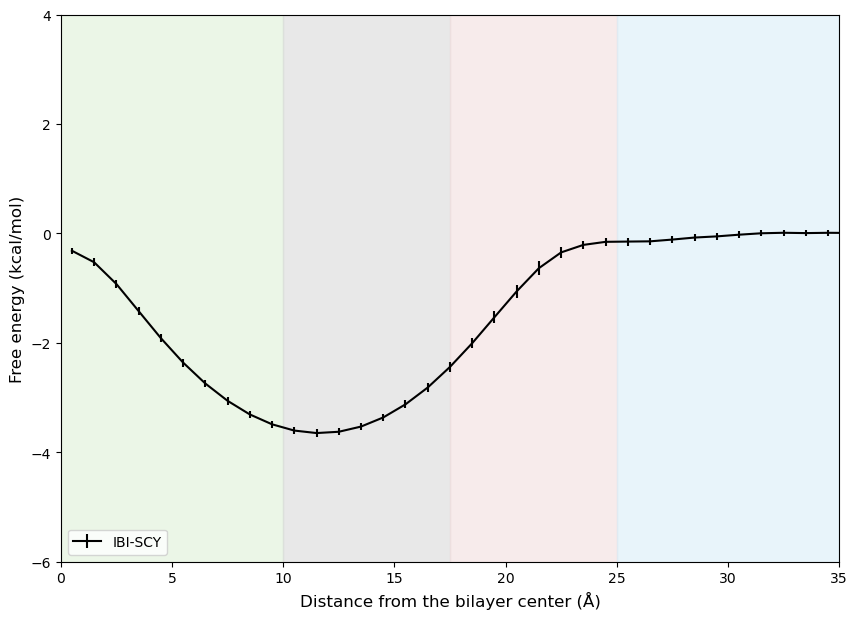

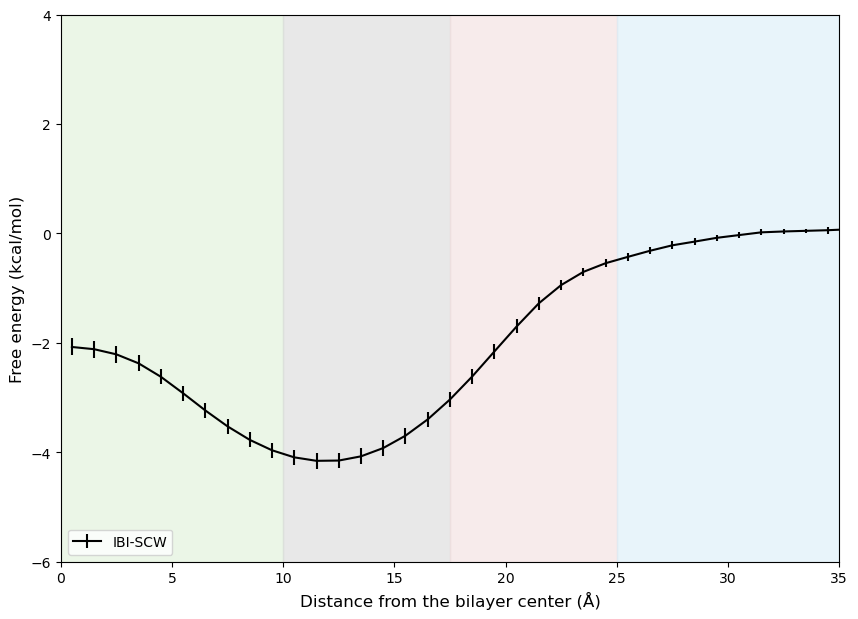

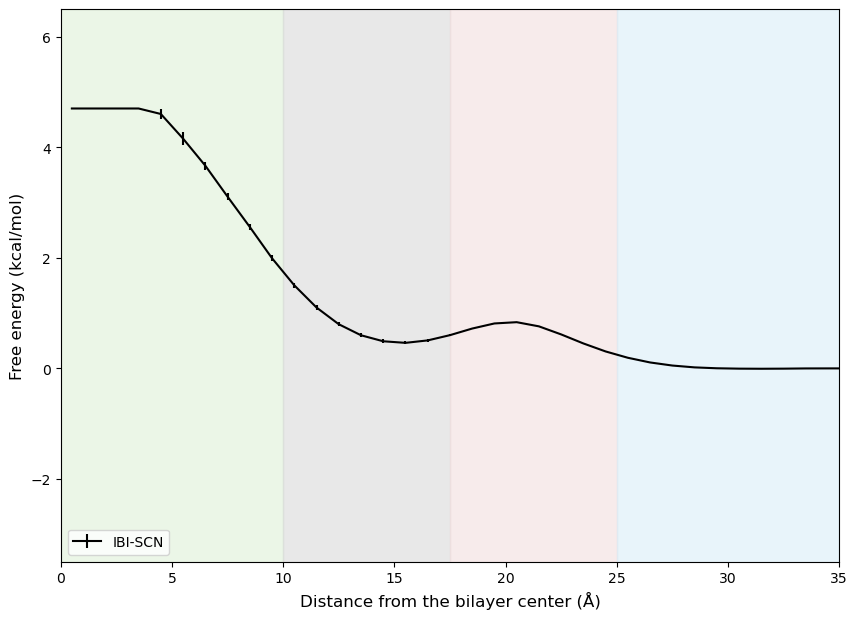

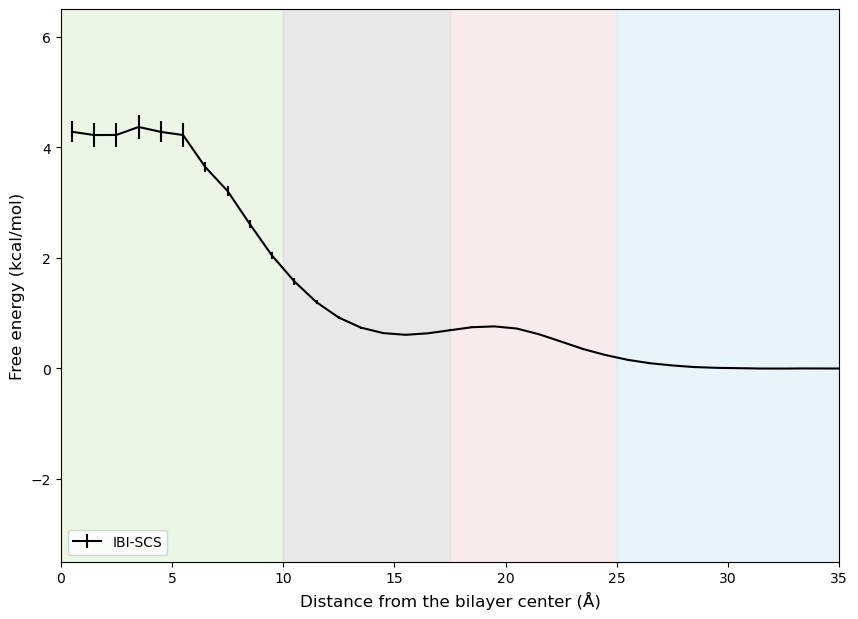

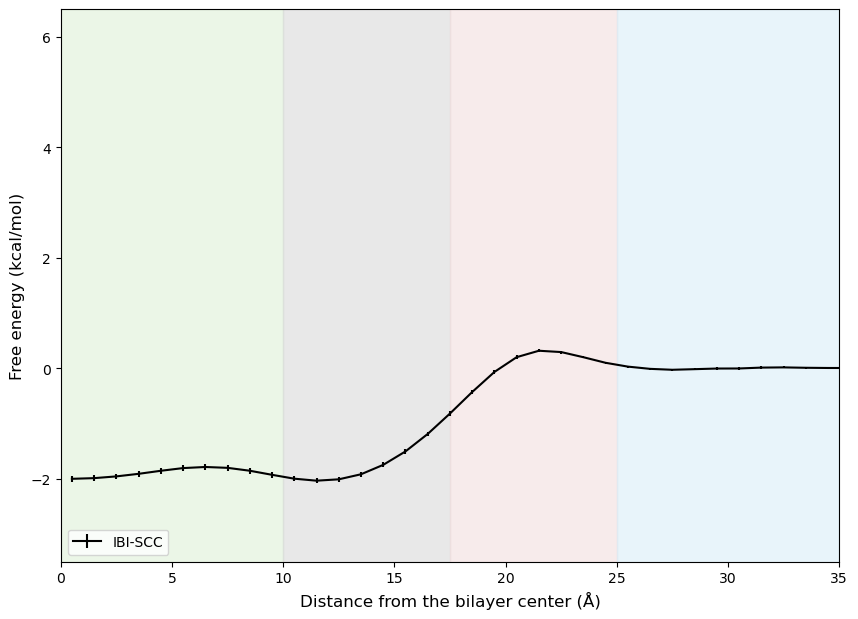

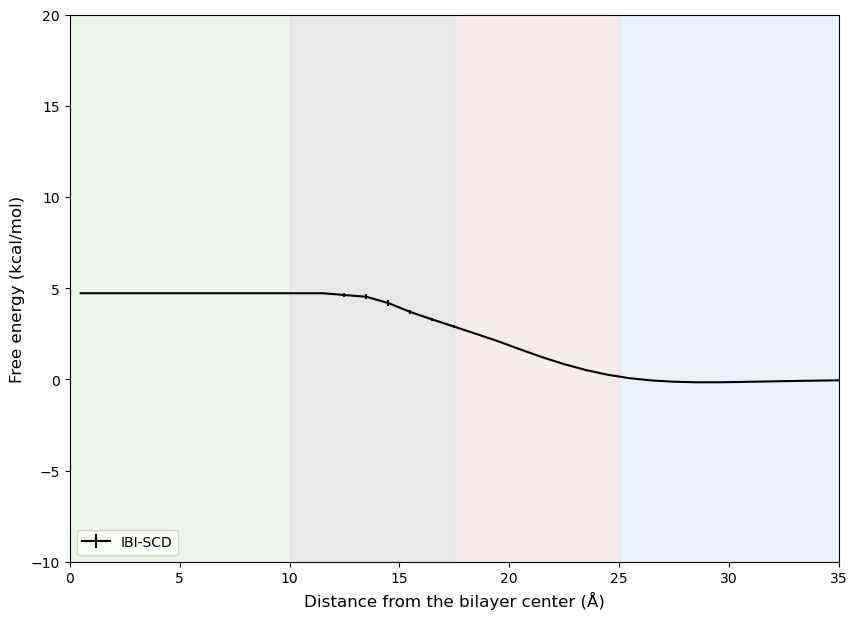

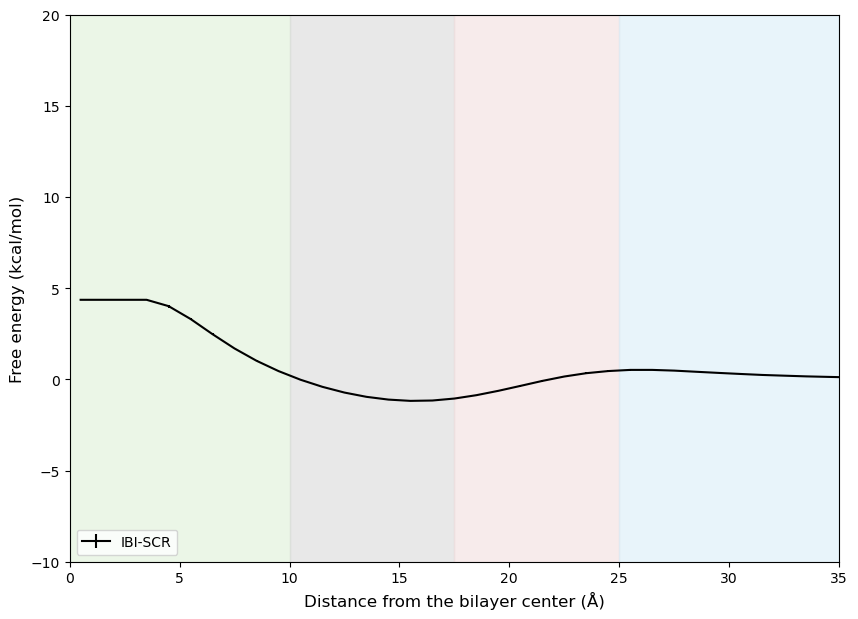

In [2]:
sc_list = ['SCA', 'SCI', 'SCF', 'SCY', 'SCW', 'SCN', 'SCS', 'SCC', 'SCD', 'SCR']

aa_list = ['ALA', 'ILE', 'PHE', 'TYR', 'TRP', 'ASN', 'SER', 'CYS', 'ASP', 'ARG']

min_pmfs = [-6, -6, -6, -6, -6, -3.5, -3.5, -3.5, -10, -10]
max_pmfs = [2, 2, 4, 4, 4, 6.5, 6.5, 6.5, 20, 20]

for i in range(len(sc_list)):
    plot_pmf(sc_list[i], aa_list[i], max_pmfs[i], min_pmfs[i])
    superposition(aa_list[i])
